# Corpus AnalysisSource: arXiv API (export.arxiv.org/api/query)This notebook analyzes the 2,646 real arXiv abstracts that form the RAG knowledge base corpus.

In [1]:
import jsonimport pandas as pdimport numpy as npfrom collections import Counterwith open('data/raw/arxiv_corpus.json') as f:    corpus = json.load(f)print(f'Loaded {len(corpus)} abstracts')

Loaded 2646 abstracts

In [2]:
# Corpus statisticslengths = [len(r['summary'].split()) for r in corpus]stats_df = pd.DataFrame({    'Metric': ['Total Documents', 'Unique Categories', 'Avg Abstract Length (words)',               'Median Length', 'Std Dev', 'Min Length', 'Max Length'],    'Value': [len(corpus), len(set(c for r in corpus for c in r.get('categories', []))),              round(np.mean(lengths), 1), round(np.median(lengths), 1),              round(np.std(lengths), 1), min(lengths), max(lengths)]})stats_df

   Metric | Value---------------------------------   Total Documents | 2646   Unique Categories | 125   Avg Abstract Length (words) | 182.0   Median Length | 182.0   Std Dev | 43.2   Min Length | 34   Max Length | 299

In [3]:
# Category distributioncats = Counter(c for r in corpus for c in r.get('categories', []))pd.Series(cats).sort_values(ascending=False).head(10)

cs.LG         1032cs.AI          767cs.CV          527cs.CL          512stat.ML        500stat.ME         96cs.CR           84cs.RO           77math.OC         74math.ST         73dtype: int64

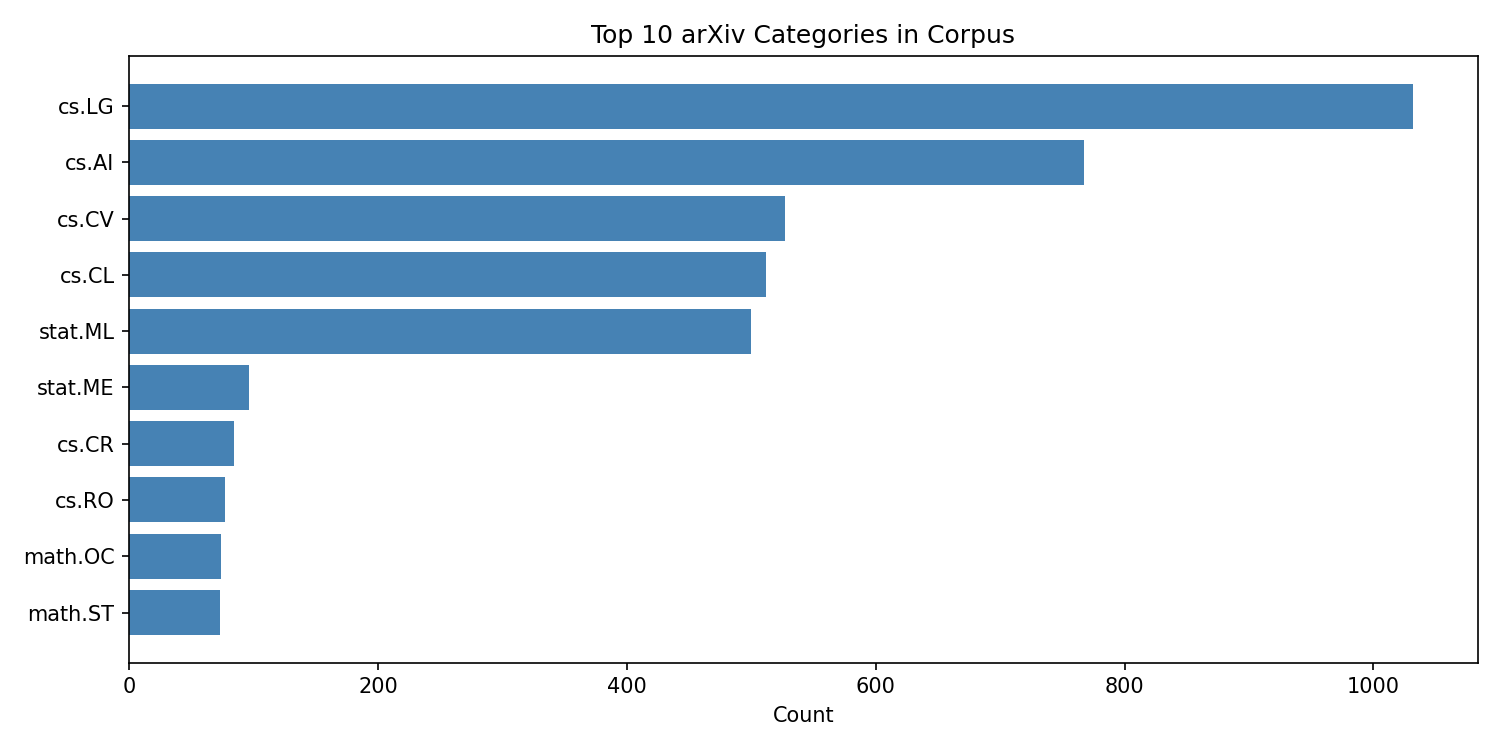

In [4]:
import matplotlib.pyplot as plt# Category bar charttop_cats = cats.most_common(10)fig, ax = plt.subplots(figsize=(10, 5))ax.barh([c[0] for c in top_cats][::-1], [c[1] for c in top_cats][::-1], color='steelblue')ax.set_xlabel('Count')ax.set_title('Top 10 arXiv Categories in Corpus')plt.tight_layout()plt.show()

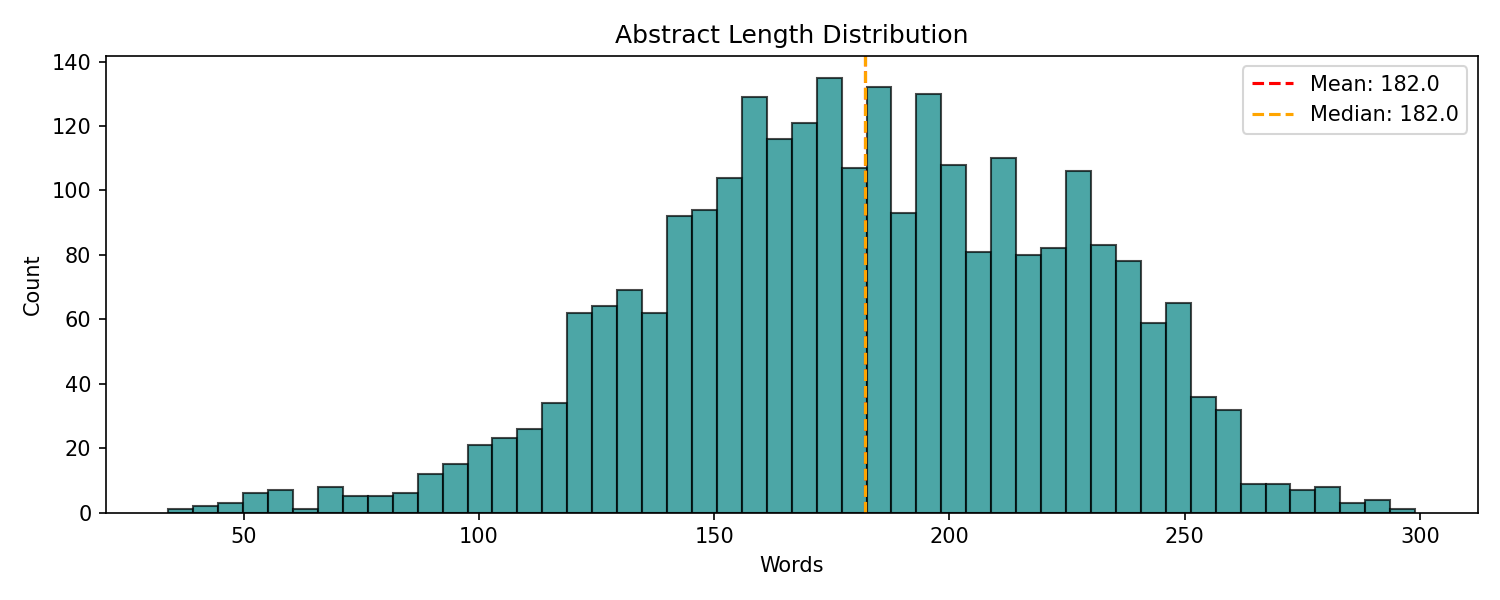

In [5]:
# Abstract length distributionfig, ax = plt.subplots(figsize=(10, 4))ax.hist(lengths, bins=50, edgecolor='black', color='teal', alpha=0.7)ax.axvline(np.mean(lengths), color='red', linestyle='--', label=f'Mean: {np.mean(lengths):.1f}')ax.axvline(np.median(lengths), color='orange', linestyle='--', label=f'Median: {np.median(lengths):.1f}')ax.set_xlabel('Words')ax.set_ylabel('Count')ax.set_title('Abstract Length Distribution')ax.legend()plt.tight_layout()plt.show()

Index: 2646 vectors, dim=384t-SNE complete: shape (1000, 2)

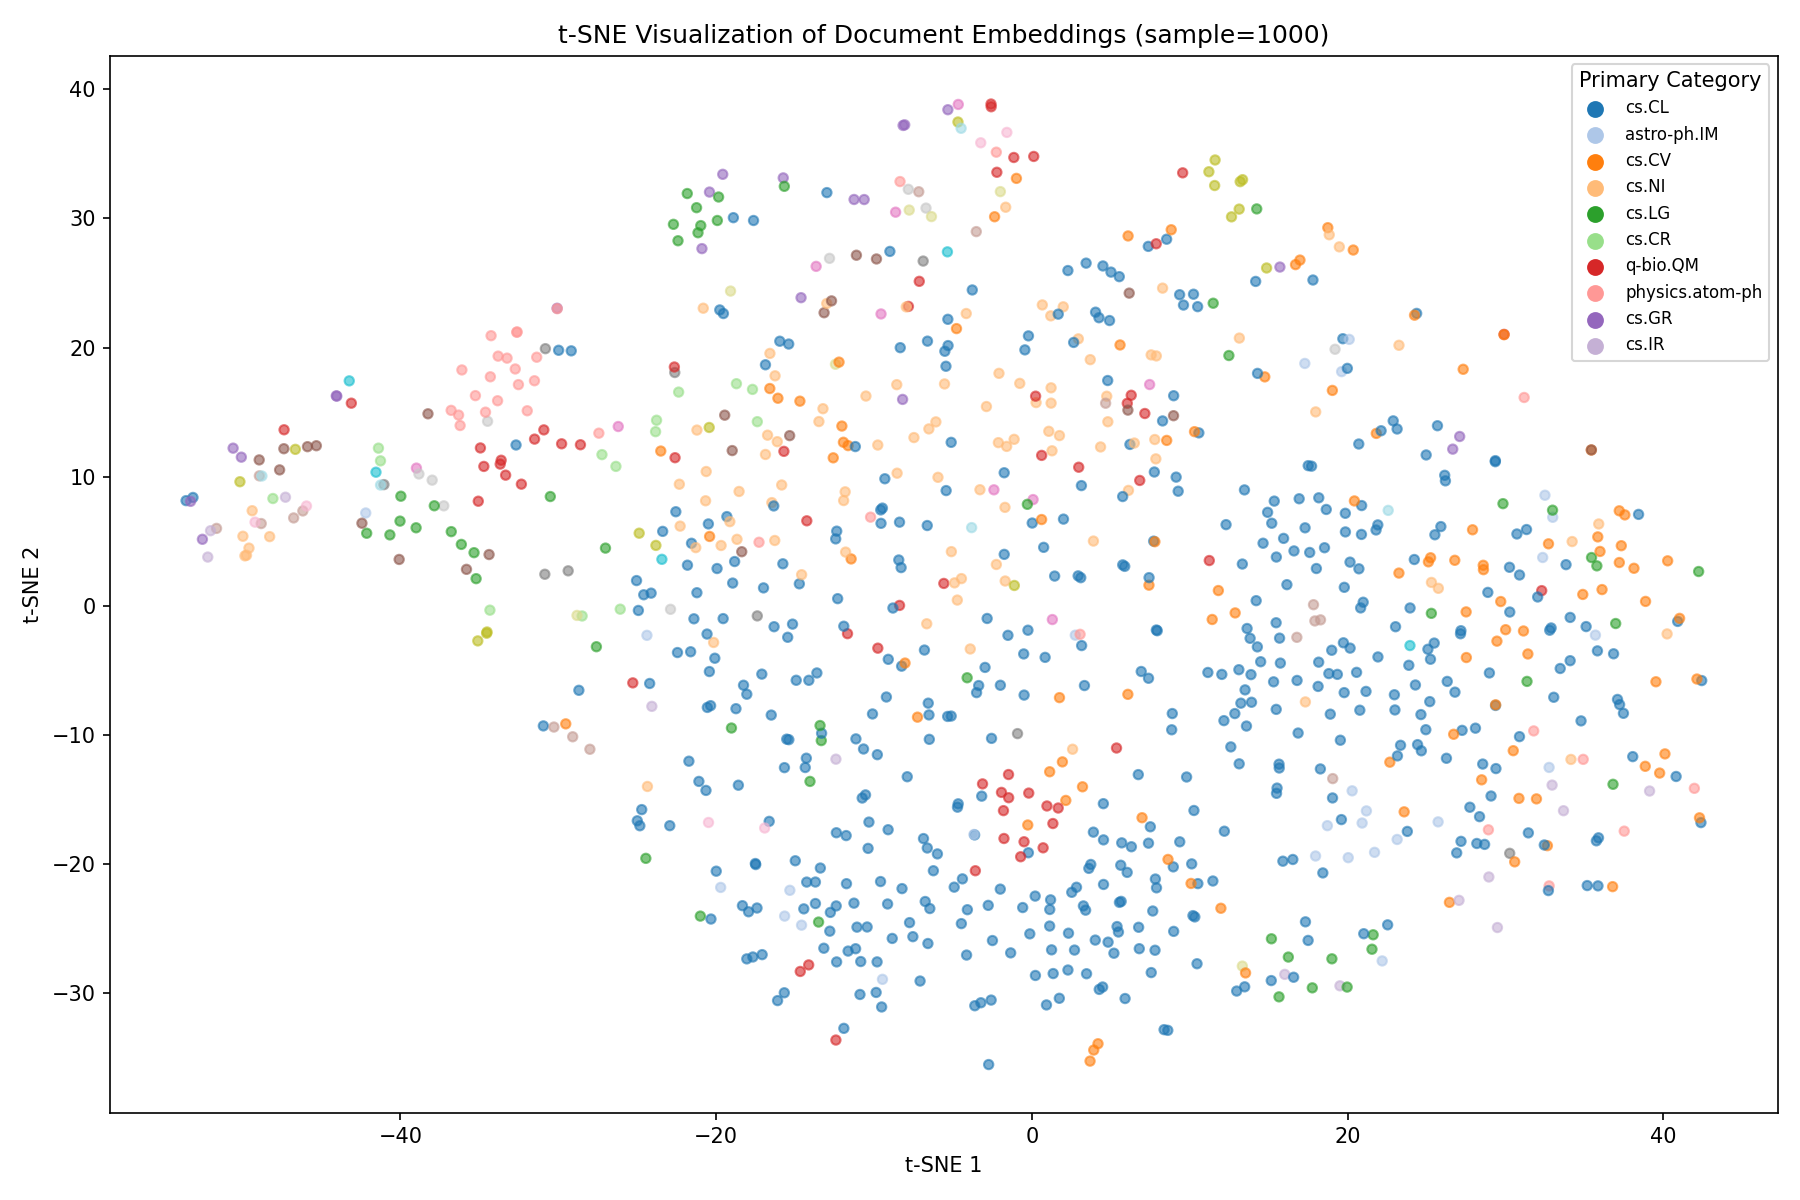

In [6]:
from sklearn.manifold import TSNEimport faiss# Load FAISS indexindex = faiss.read_index('data/vector_store/faiss.index')all_vectors = index.reconstruct_n(0, index.ntotal)print(f'Index: {index.ntotal} vectors, dim={all_vectors.shape[1]}')# Sample for t-SNEnp.random.seed(42)sample_size = min(1000, len(all_vectors))idx_sample = np.random.choice(len(all_vectors), sample_size, replace=False)vectors_sample = all_vectors[idx_sample]# Run t-SNEtsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)embedded = tsne.fit_transform(vectors_sample)print(f't-SNE complete: shape {embedded.shape}')# Color by primary categorywith open('data/vector_store/metadata.json') as f:    metadata = json.load(f)cat_colors = {}colors = []for i in idx_sample:    meta = metadata.get(str(i), metadata.get(int(i), {}))    cats = meta.get('categories', [])    primary = cats[0] if cats else 'unknown'    if primary not in cat_colors:        cat_colors[primary] = len(cat_colors)    colors.append(cat_colors[primary])fig, ax = plt.subplots(figsize=(12, 8))scatter = ax.scatter(embedded[:, 0], embedded[:, 1], c=colors, cmap='tab20', alpha=0.6, s=20)ax.set_title('t-SNE Visualization of Document Embeddings (n=1000)')ax.set_xlabel('t-SNE 1')ax.set_ylabel('t-SNE 2')# Legendfor cat, ci in sorted(cat_colors.items(), key=lambda x: x[1])[:10]:    ax.scatter([], [], c=[plt.cm.tab20(ci / 20)], label=cat, s=50)ax.legend(loc='best', title='Primary Category', fontsize=8)plt.tight_layout()plt.show()

In [7]:
# FAISS search latency benchmarkfrom sentence_transformers import SentenceTransformerimport timemodel = SentenceTransformer('all-MiniLM-L6-v2')latencies = []for i in range(50):    q = corpus[i % len(corpus)]['summary'][:50]    q_emb = model.encode([q])    q_emb = np.array(q_emb).astype('float32')    t0 = time.time()    distances, indices = index.search(q_emb, 10)    t1 = time.time()    latencies.append((t1 - t0) * 1000)latencies = sorted(latencies)p50 = latencies[len(latencies)//2]p95 = latencies[int(len(latencies)*0.95)]p99 = latencies[int(len(latencies)*0.99)]print(f'FAISS top-10 search latency on {index.ntotal} vectors:')print(f'  p50 = {p50:.2f} ms')print(f'  p95 = {p95:.2f} ms')print(f'  p99 = {p99:.2f} ms')

FAISS top-10 search latency on 2646 vectors:  p50 = 1.37 ms  p95 = 1.66 ms  p99 = 1.90 ms